In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-classification/Training/no_tumor/image(84).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(44).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(245).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/6.jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(238).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(196).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(108).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(310).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image (5).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(186).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(29).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(140).jpg
/kaggle/input/brain-tumor-classification/Training/no_tumor/image(224).jpg
/kaggle/input/brain-tumor-classification/Training/n

## Brain Tumor Classification Using Transfer Learning (MobileNetV2, EfficientNetB0, ResNet50)

**This project classifies MRI brain images into tumor categories using advanced deep learning models. It compares MobileNetV2, EfficientNetB0, and ResNet50 with data augmentation and fine-tuning. ResNet50 achieves the highest accuracy, demonstrating strong feature extraction and generalization. The system provides a reliable solution for automated medical image classification.**

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Load Dataset Folders

In [3]:
train_dir = "/kaggle/input/brain-tumor-classification/Training"
validation_dir = "/kaggle/input/brain-tumor-classification/Testing"

In [4]:
print("Training folder exists:", os.path.exists(train_dir))
print("Testing folder exists:", os.path.exists(validation_dir))

Training folder exists: True
Testing folder exists: True


## Check Class Names

In [5]:
classes_train = sorted(os.listdir(train_dir))

print("Training data List :", classes_train)

Training data List : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [6]:
classes_test = sorted(os.listdir(validation_dir))

print("Testing data List :",classes_test)

Testing data List : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## Count Images per Class

In [7]:
train_counts = {}
for cls in classes_train:
    folder = os.path.join(train_dir,cls)
    train_counts[cls] = len(os.listdir(folder))
print("Training class counts :")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")
    
test_counts = {}
for cls in classes_test:
    folder = os.path.join(validation_dir,cls)
    test_counts[cls] = len(os.listdir(folder))
print("Testing class count :")
for cls, count in test_counts.items():
    print(f"{cls}:{count}")

Training class counts :
glioma_tumor: 826
meningioma_tumor: 822
no_tumor: 395
pituitary_tumor: 827
Testing class count :
glioma_tumor:100
meningioma_tumor:115
no_tumor:105
pituitary_tumor:74


## Display Sample Images

In [8]:
import matplotlib.pyplot as plt
import cv2
import random
from tqdm import tqdm

In [9]:
image_size = 150

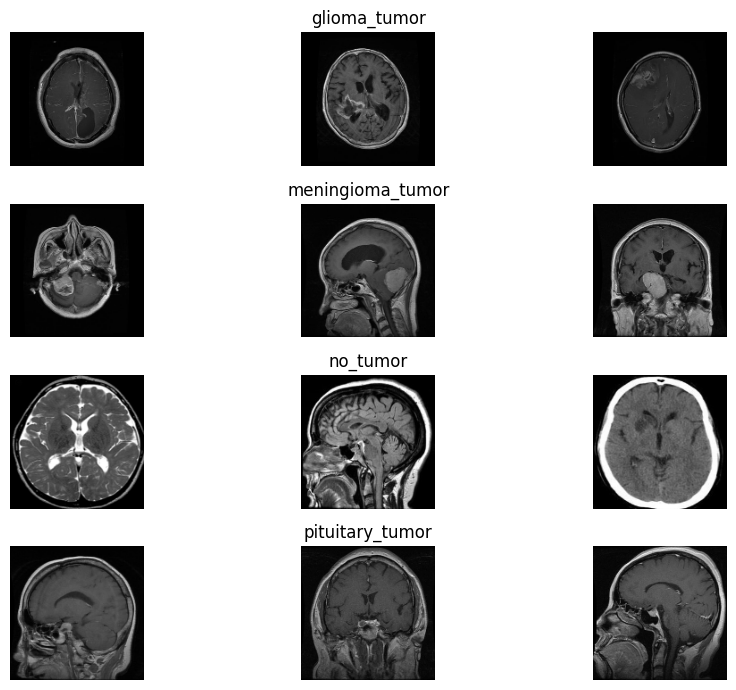

In [10]:
plt.figure(figsize=(10,7))

for i, cls in enumerate(classes_train):
    folderpath = os.path.join(train_dir,cls)
    img_list = os.listdir(folderpath)


    sample_img = random.sample(img_list,3)


    for j,img_name in enumerate (sample_img):
        img_path = os.path.join(folderpath,img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(image_size, image_size))

        plt.subplot(len(classes_train),3,i*3+j+1)
        plt.imshow(img)
        plt.axis("off")
        if j == 1:
            plt.title(cls)


plt.tight_layout()
plt.show()

## Load All Images

In [11]:
x = []
y = []
image_size = 150

In [12]:
for cls in classes_train:
    folderpath = os.path.join(train_dir,cls)
    for img_name in tqdm(os.listdir(folderpath)):
        img = cv2.imread(os.path.join(folderpath,img_name))
        img = cv2.resize(img,(image_size,image_size))
        x.append(img)
        y.append(cls)

100%|██████████| 827/827 [00:11<00:00, 73.81it/s]


In [13]:
for cls in classes_test:
    folderpath = os.path.join(validation_dir,cls)
    for img_name in tqdm(os.listdir(folderpath)):
        img = cv2.imread(os.path.join(folderpath,img_name))
        img = cv2.resize(img,(image_size,image_size))
        x.append(img)
        y.append(cls)

100%|██████████| 74/74 [00:01<00:00, 59.46it/s]


In [14]:
x = np.array(x)
y = np.array(y)
print("x_shape :",x.shape)
print("y_shape :", y.shape)

x_shape : (3264, 150, 150, 3)
y_shape : (3264,)


## Train-Test Split + One-Hot Encoding

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
y_train_encoded = [classes_train.index(label) for label in y_train]
y_test_encoded = [classes_train.index(label) for label in y_test]

In [18]:
import tensorflow
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train_encoded)
y_test = to_categorical(y_test_encoded)

2025-11-24 04:50:18.503540: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-24 04:50:18.503623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-24 04:50:18.505675: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [19]:
print("train shape: ",x_train.shape,y_train.shape)
print("test shape :", x_test.shape,y_test.shape)

train shape:  (2611, 150, 150, 3) (2611, 4)
test shape : (653, 150, 150, 3) (653, 4)


## MobileNetV2 Model

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [21]:
datagen_mobilenet = ImageDataGenerator(
    rescale=1./255.,        
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False    
)
datagen_mobilenet.fit(x_train)

In [22]:
base_model = MobileNetV2(include_top=False,
                         weights="imagenet",
                         input_shape=(150,150,3)
                        )

9406464/9406464 [==============================] - 0s 0us/step


In [23]:
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256,activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(len(classes_train),activation = "softmax")(x)

In [24]:
model_mobile = Model(inputs = base_model.input,outputs = output)

In [25]:
optimizer= Adam(learning_rate=1e-4)

In [26]:
model_mobile.compile(
    optimizer= optimizer,
    loss='categorical_crossentropy',
    metrics=["accuracy"],
)

In [27]:
model_mobile.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 75, 75, 32)           864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 75, 75, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 75, 75, 32)           0         ['bn_Conv1[0][0]']        

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]


In [29]:
history_mobile = model_mobile.fit(
    datagen_mobilenet.flow(x_train,y_train,batch_size = 30),
    validation_data = (x_test/255,y_test),
    epochs=15,
    callbacks = callbacks

)

Epoch 1/15
88/88 [==============================] - 54s 538ms/step - loss: 0.8309 - accuracy: 0.6859 - val_loss: 1.0515 - val_accuracy: 0.5758 - lr: 1.0000e-04
Epoch 2/15
88/88 [==============================] - 47s 533ms/step - loss: 0.4677 - accuracy: 0.8315 - val_loss: 0.7707 - val_accuracy: 0.7167 - lr: 1.0000e-04
Epoch 3/15
88/88 [==============================] - 46s 520ms/step - loss: 0.3834 - accuracy: 0.8675 - val_loss: 0.8593 - val_accuracy: 0.7305 - lr: 1.0000e-04
Epoch 4/15
88/88 [==============================] - 45s 511ms/step - loss: 0.2897 - accuracy: 0.8924 - val_loss: 0.8838 - val_accuracy: 0.7381 - lr: 1.0000e-04
Epoch 5/15
88/88 [==============================] - 50s 567ms/step - loss: 0.2482 - accuracy: 0.9043 - val_loss: 0.8136 - val_accuracy: 0.7366 - lr: 3.0000e-05
Epoch 6/15
88/88 [==============================] - 45s 506ms/step - loss: 0.2121 - accuracy: 0.9265 - val_loss: 0.7327 - val_accuracy: 0.7703 - lr: 3.0000e-05
Epoch 7/15
88/88 [======================

## EfficientNetB0 Model

In [30]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications.efficientnet import preprocess_input

In [31]:
datagen_efficient = ImageDataGenerator(        
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,    
    fill_mode='nearest',
    preprocessing_function=preprocess_input
)
datagen_efficient.fit(x_train)

In [32]:
base_model = EfficientNetB0(include_top=False,
                         weights="imagenet",
                         input_shape=(150,150,3)
                        )

16705208/16705208 [==============================] - 0s 0us/step


In [33]:
for layer in base_model.layers[:-80]:
    layer.trainable = False
for layer in base_model.layers[-80:]:
    layer.trainable = True


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256,activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(classes_train),activation = "softmax")(x)


In [34]:
model_efficient = Model(inputs = base_model.input, outputs = output)

In [35]:
optimizer = Adam(learning_rate=1e-4)

In [36]:
model_efficient.compile(optimizer= optimizer,
                        loss="categorical_crossentropy",
                        metrics=["accuracy"]
                       )

In [37]:
model_efficient.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 150, 150, 3)          0         ['input_2[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 150, 150, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 150, 150, 3)          0         ['normalization[0][0]'] 

In [38]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

val_x = preprocess_input(x_test.copy())

In [39]:
history_efficient = model_efficient.fit(datagen_efficient.flow(x_train,y_train,batch_size = 32),
                                        validation_data=(val_x,y_test),
                                        epochs=25,
                                        callbacks = callbacks
                                       )

Epoch 1/25
82/82 [==============================] - 109s 1s/step - loss: 1.3624 - accuracy: 0.4703 - val_loss: 0.9479 - val_accuracy: 0.6493 - lr: 1.0000e-04
Epoch 2/25
82/82 [==============================] - 96s 1s/step - loss: 0.8563 - accuracy: 0.6691 - val_loss: 0.6366 - val_accuracy: 0.7565 - lr: 1.0000e-04
Epoch 3/25
82/82 [==============================] - 86s 1s/step - loss: 0.6646 - accuracy: 0.7442 - val_loss: 0.4985 - val_accuracy: 0.8025 - lr: 1.0000e-04
Epoch 4/25
82/82 [==============================] - 95s 1s/step - loss: 0.5794 - accuracy: 0.7871 - val_loss: 0.4810 - val_accuracy: 0.8132 - lr: 1.0000e-04
Epoch 5/25
82/82 [==============================] - 86s 1s/step - loss: 0.5131 - accuracy: 0.8070 - val_loss: 0.5181 - val_accuracy: 0.8132 - lr: 1.0000e-04
Epoch 6/25
82/82 [==============================] - 85s 1s/step - loss: 0.4690 - accuracy: 0.8269 - val_loss: 0.4497 - val_accuracy: 0.8285 - lr: 1.0000e-04
Epoch 7/25
82/82 [==============================] - 85s 1

## ResNet50 Model

In [40]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications.resnet50 import preprocess_input

In [41]:
datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True
)
datagen_resnet.fit(x_train)

In [42]:
base_model = ResNet50(include_top=False,
                         weights="imagenet",
                         input_shape=(150,150,3)
                        )

94765736/94765736 [==============================] - 0s 0us/step


In [43]:
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256,activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(classes_train),activation = "softmax")(x)


In [44]:
model_resnet = Model(inputs = base_model.input, outputs = output)

In [45]:
optimizer = Adam(learning_rate=1e-4)

In [46]:
model_resnet.compile(optimizer=optimizer,
                        loss="categorical_crossentropy",
                        metrics=["accuracy"]
                       )

In [47]:
model_resnet.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 156, 156, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 75, 75, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 75, 75, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                        

In [48]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
]

In [49]:
history_resnet = model_resnet.fit(datagen_resnet.flow(x_train,y_train,batch_size = 32),
                                        validation_data=(preprocess_input(x_test),y_test),
                                        epochs=25,
                                        callbacks=callbacks
                                       )

Epoch 1/25
82/82 [==============================] - 229s 3s/step - loss: 1.0281 - accuracy: 0.6136 - val_loss: 0.5533 - val_accuracy: 0.7611 - lr: 1.0000e-04
Epoch 2/25
82/82 [==============================] - 219s 3s/step - loss: 0.5424 - accuracy: 0.7978 - val_loss: 0.4415 - val_accuracy: 0.8438 - lr: 1.0000e-04
Epoch 3/25
82/82 [==============================] - 225s 3s/step - loss: 0.3944 - accuracy: 0.8606 - val_loss: 0.3966 - val_accuracy: 0.8683 - lr: 1.0000e-04
Epoch 4/25
82/82 [==============================] - 218s 3s/step - loss: 0.3151 - accuracy: 0.8797 - val_loss: 0.4365 - val_accuracy: 0.8683 - lr: 1.0000e-04
Epoch 5/25
82/82 [==============================] - 219s 3s/step - loss: 0.2631 - accuracy: 0.9046 - val_loss: 0.3849 - val_accuracy: 0.8943 - lr: 1.0000e-04
Epoch 6/25
82/82 [==============================] - 214s 3s/step - loss: 0.2233 - accuracy: 0.9211 - val_loss: 0.3301 - val_accuracy: 0.9096 - lr: 1.0000e-04
Epoch 7/25
82/82 [==============================] - 

**ResNet50** performed the best among **the three models**. It achieved the **highest validation accuracy and the lowest loss,** indicating strong generalization. **EfficientNetB0** delivered moderate results, while **MobileNetV2** showed comparatively lower accuracy. Overall,**ResNet50 is the most reliable model.**